In [22]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


### Data Augmentation 


In [ ]:
import numpy as np
data = np.load("D:/Semester_2/Deep Learning/Assignments/DL_PA2/DL_PA2/processed_data/quickdraw_train.npz")

print("Keys in dataset:", data.files)

X = data['x_train']
y = data['y_train']


Keys in dataset: ['x_train', 'y_train', 'class_names']


In [ ]:
X = X.reshape(-1, 28, 28)

class AddNoise(object):
    def __call__(self, tensor):
        return tensor + 0.02 * torch.randn_like(tensor)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    AddNoise(),                
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class QuickDrawDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].astype(np.uint8)

        if self.transform:
            image = self.transform(image)

        image = image.view(-1)  # flatten to 784

        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label


full_dataset = QuickDrawDataset(X, y, transform=None)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)

# Create TWO separate dataset 
train_dataset = QuickDrawDataset(X, y, transform=train_transform)
val_dataset   = QuickDrawDataset(X, y, transform=val_transform)

# Apply indices
train_dataset = Subset(train_dataset, train_indices.indices)
val_dataset   = Subset(val_dataset, val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

### Part A

In [4]:
class PartAMLP(nn.Module):
    def __init__(self ,input_size =784 ,num_classes=15) :
        super(PartAMLP ,self).__init__()
        self.fc1 = nn.Linear(input_size, 2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, num_classes)
        

    def forward(self , x):
        x = self.fc1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = F.relu(x)
        
        x = self.fc3(x)
        return x

In [5]:

model_A = PartAMLP()
criterion = nn.CrossEntropyLoss() # Common for multi-class classification
optimizer = optim.Adam(model_A.parameters(), lr=0.001)
print(model_A)

PartAMLP(
  (fc1): Linear(in_features=784, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=15, bias=True)
)


In [7]:
epochs = 30
train_loss_A = []
train_acc_A = []
val_acc_A = []

for epoch in range(epochs):
    
    # ----- Training -----
    model_A.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    
    for xb, yb in train_loader:
        outputs = model_A(xb)
        loss = criterion(outputs, yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += yb.size(0)
        train_correct += (predicted == yb).sum().item()
    
    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_loss_A.append(train_loss)
    train_acc_A.append(train_accuracy)
    
    
    # ----- Validation -----
    model_A.eval()
    val_correct = 0
    val_total = 0
    
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model_A(xb)
            _, predicted = torch.max(outputs, 1)
            
            val_total += yb.size(0)
            val_correct += (predicted == yb).sum().item()
    
    val_accuracy = 100 * val_correct / val_total
    val_acc_A.append(val_accuracy)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")
    

print("\nTraining Complete!")
print(f"Final Train Accuracy: {train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/30] Train Loss: 0.8520 | Train Acc: 71.82% | Val Acc: 72.21%
Epoch [2/30] Train Loss: 0.7463 | Train Acc: 75.35% | Val Acc: 75.98%
Epoch [3/30] Train Loss: 0.6753 | Train Acc: 77.35% | Val Acc: 74.60%
Epoch [4/30] Train Loss: 0.6139 | Train Acc: 79.40% | Val Acc: 77.01%
Epoch [5/30] Train Loss: 0.5649 | Train Acc: 81.06% | Val Acc: 77.79%
Epoch [6/30] Train Loss: 0.5235 | Train Acc: 82.32% | Val Acc: 77.15%
Epoch [7/30] Train Loss: 0.4808 | Train Acc: 83.83% | Val Acc: 79.01%
Epoch [8/30] Train Loss: 0.4418 | Train Acc: 84.86% | Val Acc: 78.12%
Epoch [9/30] Train Loss: 0.4043 | Train Acc: 86.19% | Val Acc: 78.87%
Epoch [10/30] Train Loss: 0.3654 | Train Acc: 87.47% | Val Acc: 79.10%
Epoch [11/30] Train Loss: 0.3348 | Train Acc: 88.33% | Val Acc: 78.88%
Epoch [12/30] Train Loss: 0.2964 | Train Acc: 89.70% | Val Acc: 78.76%
Epoch [13/30] Train Loss: 0.2741 | Train Acc: 90.36% | Val Acc: 78.44%
Epoch [14/30] Train Loss: 0.2378 | Train Acc: 91.79% | Val Acc: 78.97%
Epoch [15/30] T

### Part B

In [ ]:
class PartBMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PartBMLP, self).__init__()
        
        # 5 hidden layers
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        
        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        
        self.fc6 = nn.Linear(128, num_classes)
        

    def forward(self, x):
        x = x.view(-1, 784)
        
        x = F.relu(self.bn1(self.fc1(x)))
        
        x = F.relu(self.bn2(self.fc2(x)))
        
        x = F.relu(self.bn3(self.fc3(x)))
        
        x = F.relu(self.bn4(self.fc4(x)))
        
        x = F.relu(self.bn5(self.fc5(x)))
        
        x = self.fc6(x)
        return x

In [ ]:
model_B = PartBMLP()
criterion_B = nn.CrossEntropyLoss() 
optimizer_B = optim.Adam(model_B.parameters(), lr=0.001)
print(model_B)

PartBMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc6): Linear(in_features=128, out_features=15, bias=True)
)


In [11]:
epochs = 30

train_loss_B = []
train_acc_B = []
val_acc_B = []

for epoch in range(epochs):
    
    # ----- Training -----
    model_B.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for xb, yb in train_loader:
        outputs = model_B(xb)
        loss = criterion_B(outputs, yb)
        
        optimizer_B.zero_grad()
        loss.backward()
        optimizer_B.step()
        
        train_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += yb.size(0)
        train_correct += (predicted == yb).sum().item()
    
    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_loss_B.append(train_loss)
    train_acc_B.append(train_accuracy)
    
    
    # ----- Validation -----
    model_B.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model_B(xb)
            _, predicted = torch.max(outputs, 1)
            
            val_total += yb.size(0)
            val_correct += (predicted == yb).sum().item()
    
    val_accuracy = 100 * val_correct / val_total
    val_acc_B.append(val_accuracy)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")
    

print("\nTraining Complete!")
print(f"Final Train Accuracy: {train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/30] Train Loss: 0.8131 | Train Acc: 72.73% | Val Acc: 74.04%
Epoch [2/30] Train Loss: 0.7256 | Train Acc: 75.70% | Val Acc: 76.06%
Epoch [3/30] Train Loss: 0.6682 | Train Acc: 77.70% | Val Acc: 76.79%
Epoch [4/30] Train Loss: 0.6229 | Train Acc: 79.22% | Val Acc: 77.47%
Epoch [5/30] Train Loss: 0.5782 | Train Acc: 80.64% | Val Acc: 77.95%
Epoch [6/30] Train Loss: 0.5504 | Train Acc: 81.47% | Val Acc: 78.28%
Epoch [7/30] Train Loss: 0.5209 | Train Acc: 82.55% | Val Acc: 78.42%
Epoch [8/30] Train Loss: 0.4960 | Train Acc: 83.22% | Val Acc: 78.93%
Epoch [9/30] Train Loss: 0.4691 | Train Acc: 84.19% | Val Acc: 78.93%
Epoch [10/30] Train Loss: 0.4484 | Train Acc: 84.81% | Val Acc: 79.08%
Epoch [11/30] Train Loss: 0.4259 | Train Acc: 85.51% | Val Acc: 79.04%
Epoch [12/30] Train Loss: 0.4098 | Train Acc: 86.04% | Val Acc: 78.96%
Epoch [13/30] Train Loss: 0.3894 | Train Acc: 86.62% | Val Acc: 78.97%
Epoch [14/30] Train Loss: 0.3747 | Train Acc: 87.06% | Val Acc: 79.39%
Epoch [15/30] T

### Part C (Best_Model)

In [ ]:
class Best_MLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(Best_MLP, self).__init__()
        
        # 3 hidden layers
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Output layer
        self.fc4 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.35)
        

    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        x = F.gelu(self.fc1(x))
        x = self.dropout(x)

        x = F.gelu(self.fc2(x))
        x = self.dropout(x)
 
        x = F.gelu(self.fc3(x))
        x = self.dropout(x)

        x = self.fc4(x)
        return x

In [ ]:
model = Best_MLP()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1.5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)
print(model)

Best_MLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=15, bias=True)
  (dropout): Dropout(p=0.35, inplace=False)
)


In [15]:
epochs = 30
train_loss_best = []
train_acc_best = []
val_acc_best = []

for epoch in range(epochs):
    
    # ----- Training -----
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += yb.size(0)
        train_correct += (predicted == yb).sum().item()
    
    scheduler.step()
    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_loss_best.append(train_loss)
    train_acc_best.append(train_accuracy)
    
    
    # ----- Validation -----
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb)
            _, predicted = torch.max(outputs, 1)
            
            val_total += yb.size(0)
            val_correct += (predicted == yb).sum().item()
    
    val_accuracy = 100 * val_correct / val_total
    val_acc_best.append(val_accuracy)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")
    

print("\nTraining Complete!")
print(f"Final Train Accuracy: {train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/30] Train Loss: 1.4270 | Train Acc: 65.22% | Val Acc: 69.12%
Epoch [2/30] Train Loss: 1.3514 | Train Acc: 68.51% | Val Acc: 71.58%
Epoch [3/30] Train Loss: 1.2981 | Train Acc: 70.61% | Val Acc: 73.15%
Epoch [4/30] Train Loss: 1.2561 | Train Acc: 72.42% | Val Acc: 74.18%
Epoch [5/30] Train Loss: 1.2255 | Train Acc: 73.51% | Val Acc: 75.70%
Epoch [6/30] Train Loss: 1.1982 | Train Acc: 74.99% | Val Acc: 76.45%
Epoch [7/30] Train Loss: 1.1761 | Train Acc: 75.55% | Val Acc: 76.67%
Epoch [8/30] Train Loss: 1.1587 | Train Acc: 76.52% | Val Acc: 77.33%
Epoch [9/30] Train Loss: 1.1352 | Train Acc: 77.24% | Val Acc: 77.27%
Epoch [10/30] Train Loss: 1.1218 | Train Acc: 78.05% | Val Acc: 78.45%
Epoch [11/30] Train Loss: 1.1018 | Train Acc: 78.86% | Val Acc: 78.33%
Epoch [12/30] Train Loss: 1.0857 | Train Acc: 79.59% | Val Acc: 78.58%
Epoch [13/30] Train Loss: 1.0760 | Train Acc: 79.89% | Val Acc: 79.13%
Epoch [14/30] Train Loss: 1.0588 | Train Acc: 80.76% | Val Acc: 79.35%
Epoch [15/30] T

### Test predictions

In [ ]:
test_data = np.load("D:/Semester_2/Deep Learning/Assignments/DL_PA2/DL_PA2/processed_data/quickdraw_test.npz")
print(test_data.files)
X_test = test_data['test_images']

X_test = X_test.reshape(-1, 28, 28)

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class TestDataset(Dataset):
    def __init__(self, X, transform=None):
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].astype(np.uint8)

        if self.transform:
            image = self.transform(image)

        image = image.view(-1)
        return image

test_dataset = TestDataset(X_test, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model.eval()
predictions = []

with torch.no_grad():
    for xb in test_loader:
        outputs = model(xb)
        _, predicted_classes = torch.max(outputs, 1)
        predictions.extend(predicted_classes.cpu().numpy())


predictions_csv = ",".join(map(str, predictions))
print(predictions_csv)

['test_images']
6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,10,1,12,13,5,14,5,8,2,12,8,0,2,13,1,11,14,10,1,5,11,0,11,5,11,11,6,10,2,9,6,7,2,0,12,2,12,4,11,4,6,3,14,13,6,5,6,2,11,10,13,6,4,12,0,0,11,14,11,0,7,1,14,5,6,5,1,9,10,14,12,1,5,5,2,7,4,14,11,9,1,7,13,12,2,1,7,9,0,4,7,9,2,13,13,7,14,3,4,5,3,0,8,14,11,11,12,1,13,10,2,1,14,1,12,7,11,3,0,4,14,1,12,6,8,0,2,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,11,7,11,2,13,10,3,12,3,8,6,11,1,9,9,8,6,0,4,1,5,5,10,6,14,10,1,13,1,1,10,5,7,14,5,1,9,6,2,6,3,8,1,1,4,7,12,9,11,13,14,4,0,8,6,4,14,1,3,10,0,11,4,11,2,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,3,12,12,3,7,13,11,2,3,0,8,12,8,6,6,1,7,12,8,0,3,14,4,12,3,6,6,2,0,9,12,11,6,3,1,5,12,3,0,6,6,11,7,13,8,12,13,9,1,5,5,14,10,14,13,0,9,10,11,7,9,3,10,11,12,13,12,6,4,14,9,7,8,10,1,14,10,2,1,10,14,12,14,0,7,7,0,5,7,5,7,12,1,7,12,11,13,4,11,5,14,11,8,7,11,12,11,4,13,1,2,4,1,0,13,9,3,10,14,6,0,4,0,10,2,2,5,14,2,3,11,13,10,4,13,9,3,8,7,13,14,7,14,0,0,14,12,11,10,0,0,

### Parameter Count

In [8]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

569871

### Part D (a) Confusion Matrix

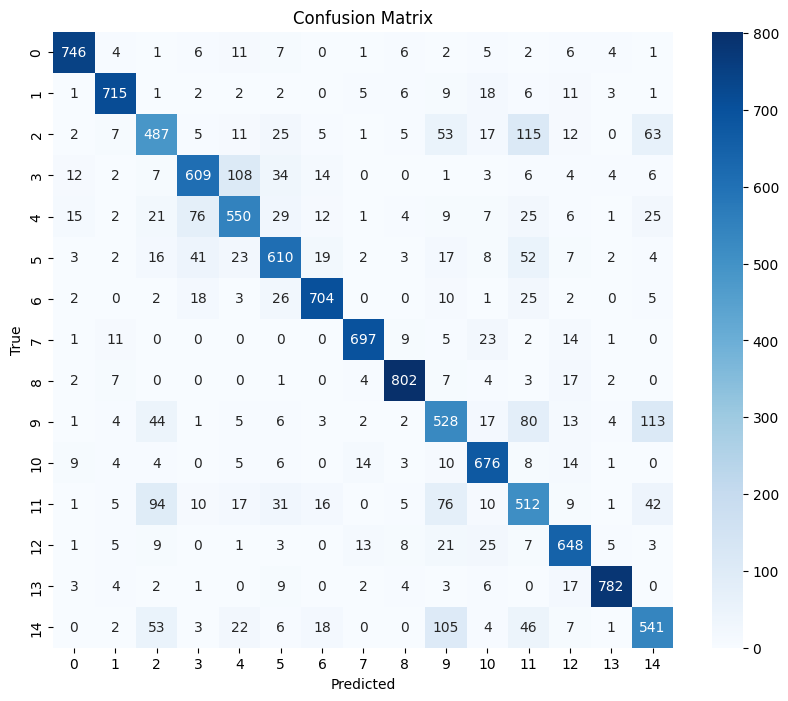

In [14]:
class_names = [
    "Apple","Banana","Cookie","Donut","Guitar",
    "House","Ice Cream","Laptop","Moon","Nail",
    "Orange","Pizza","Robot","Star","Tree"
]
def get_confusion_matrix(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm

# Generate matrix
cm = get_confusion_matrix(model, val_loader, device = "cpu")

# Plot it
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# Zero out diagonal (correct predictions)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# Find top 2 confusion pairs
flat_indices = np.argsort(cm_no_diag, axis=None)[-2:]

top_pairs = []
for idx in flat_indices:
    true_class = idx // cm.shape[1]
    pred_class = idx % cm.shape[1]
    top_pairs.append((true_class, pred_class, cm[true_class, pred_class]))

print("Top 2 confused pairs:")
for pair in top_pairs:
    print(f"True: {pair[0]} Predicted: {pair[1]} Count: {pair[2]}")

Top 2 confused pairs:
True: 9 Predicted: 14 Count: 113
True: 2 Predicted: 11 Count: 115


In [18]:
def show_images_of_class(dataset, class_idx, class_names, num_images=5):
    indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
    
    plt.figure(figsize=(10,2))
    for i in range(num_images):
        img, _ = dataset[indices[i]]
        plt.subplot(1, num_images, i+1)
        plt.imshow(img.numpy().reshape(28,28), cmap='gray')
        plt.title(class_names[class_idx])
        plt.axis('off')
    plt.show()

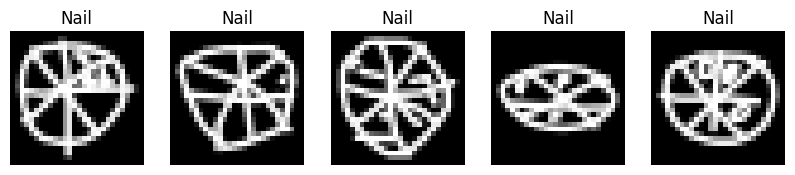

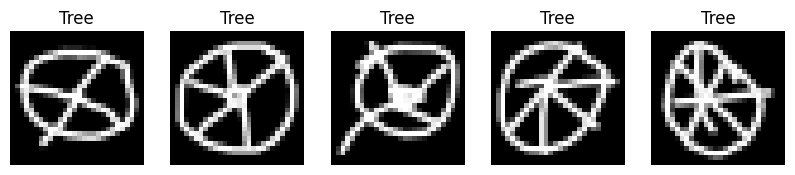

In [19]:
show_images_of_class(val_dataset, top_pairs[0][0], class_names)  # True class images
show_images_of_class(val_dataset, top_pairs[0][1], class_names)

### Part E:

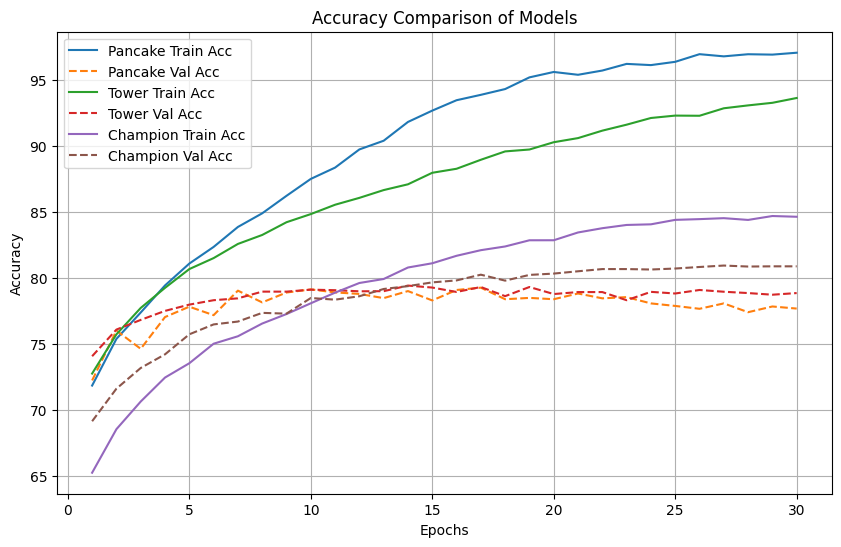

In [16]:
def plot_accuracy(pancake_train, pancake_val, tower_train, tower_val, champion_train, champion_val):
    epochs = range(1, len(pancake_train) + 1)

    plt.figure(figsize=(10,6))

    # Pancake
    plt.plot(epochs, pancake_train, label="Pancake Train Acc")
    plt.plot(epochs, pancake_val, linestyle="--", label="Pancake Val Acc")

    # Tower
    plt.plot(epochs, tower_train, label="Tower Train Acc")
    plt.plot(epochs, tower_val, linestyle="--", label="Tower Val Acc")

    # Champion
    plt.plot(epochs, champion_train, label="Champion Train Acc")
    plt.plot(epochs, champion_val, linestyle="--", label="Champion Val Acc")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Comparison of Models")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_accuracy(train_acc_A, val_acc_A, train_acc_B, val_acc_B, train_acc_best, val_acc_best)

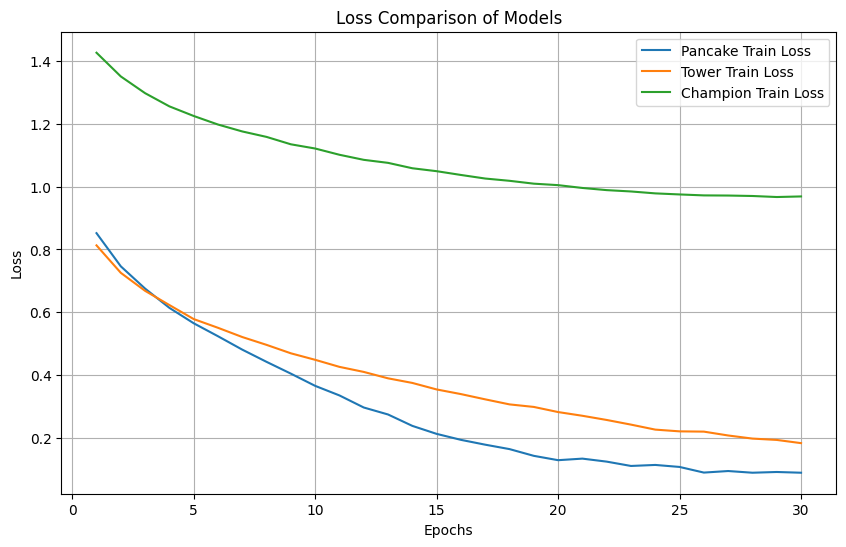

In [20]:
epochs = epochs = range(1, 31)

plt.figure(figsize=(10,6))

# Pancake
plt.plot(epochs, train_loss_A, label="Pancake Train Loss")

# Tower
plt.plot(epochs, train_loss_B, label="Tower Train Loss")

# Champion
plt.plot(epochs, train_loss_best, label="Champion Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison of Models")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

pancake_params = count_parameters(model_A)
tower_params = count_parameters(model_B)
champion_params = count_parameters(model)

print("Pancake Params:", pancake_params)
print("Tower Params:", tower_params)
print("Champion Params:", champion_params)

Pancake Params: 3721231
Tower Params: 435471
Champion Params: 569871


In [24]:
epochs = 30
data = {
    "Model": ["Pancake", "Tower", "Champion"],
    "Parameter Count": [pancake_params, tower_params, champion_params],
    "Training Epochs": [epochs, epochs, epochs],
    "Final Validation Accuracy": [
        val_acc_A[-1],
        val_acc_B[-1],
        val_acc_best[-1]
    ]
}

df = pd.DataFrame(data)
print(df)

      Model  Parameter Count  Training Epochs  Final Validation Accuracy
0   Pancake          3721231               30                     77.650
1     Tower           435471               30                     78.825
2  Champion           569871               30                     80.850
